# Homework 1 – Clustering & Disease Phenotyping
**Dataset**: Tabula Muris Senis (single-cell RNA-seq across mouse organs, young & aged)

**Goal**: Identify tissue-specific phenotypes and cell-type clusters to understand single-cell transcriptomes.

## Questions
### Conceptual (answer in PDF)  (20 pts)
1. (3 points) Define a clinical phenotype. Why is unsupervised clustering useful for discovering disease subtypes?
2. (3 points) Compare k-means vs hierarchical clustering. What assumptions do they make about cluster shape/structure?
3. (4 points) How can dimensionality reduction (PCA) help in analyzing high-dimensional scRNA-seq data?
4. (5 points) In disease phenotyping using cluster analysis, why is it important to identify  clinically recognizable clusters? Put differently: what is/are the problems if the identified  clusters are not clinically meaningful?
5. (5 points) Partitioning Around Medoids (PAM) with Gower’s distance is designed for  clustering mixed data types. Why did K-means with Euclidean distance perform better on the clinical data (with mixed data types) in Lecture 5? Similarly, why did K-means with Euclidean distance outperform K-means with Manhattan distance on the same dataset?


### Coding & Analysis (80 pts)
Complete the TODO sections below and answer the Interpretation (written) questions in the PDF.

## 0. Setup & Data Loading
Load Tabula Muris Senis dataset and select 3 tissues (Limb_Muscle, Pancreas, Spleen) with ~5000 cells total.

In [1]:
#if running in co-lab this chunk will download necessary packages
!pip install scanpy
!pip install scikit-misc
!pip install igraph leidenalg

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy import stats
from pathlib import Path
from statsmodels.stats.multitest import multipletests


# Create output directories
import os
os.makedirs('figs', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

/opt/homebrew/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
# Load pre-subset AnnData object (~5000 cells, 3 tissues: Limb_Muscle, Pancreas, Spleen)

adata = sc.read_h5ad("HW1_2026_subset.h5ad")

# Print basic info
print(adata)
print("Tissues included:", adata.obs["tissue"].unique().tolist())
print("Number of cells:", adata.n_obs)
print("Number of genes:", adata.n_vars)

AnnData object with n_obs × n_vars = 5000 × 20138
    obs: 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'n_genes', 'sex', 'subtissue', 'tissue', 'tissue_free_annotation', 'tissue_selected'
    var: 'n_cells'
    uns: 'hw1_triplet_info'
    layers: 'counts', None (.X)
Tissues included: ['Spleen', 'Limb_Muscle', 'Pancreas']
Number of cells: 5000
Number of genes: 20138


## 1. Data Preprocessing (5 pts)
Filter, normalize, and log-transform.

In [4]:
# 1. Filter cells and genes
# (we give them the function calls, but they must fill in thresholds)
sc.pp.filter_cells(adata, min_genes=200)      # TODO: confirm threshold (e.g., 200)
sc.pp.filter_genes(adata, min_cells=3)     # TODO: confirm threshold (e.g., 3)

# 2. Normalize to 10,000 reads per cell
sc.pp.normalize_total(adata, target_sum=1e4)  # TODO: confirm target sum from the comment above

# 3. Log-transform (natural log, add 1 inside log)
sc.pp.log1p(adata)

# Highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

# Scale features
sc.pp.scale(adata_hvg, max_value=10)

print("Preprocessing complete.")
print(adata)

/var/folders/qm/0prn272s7yz70q7wlyxxkhjm0000gn/T/ipykernel_9361/2744024611.py:13: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")


Preprocessing complete.
AnnData object with n_obs × n_vars = 5000 × 16557
    obs: 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'n_genes', 'sex', 'subtissue', 'tissue', 'tissue_free_annotation', 'tissue_selected'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hw1_triplet_info', 'log1p', 'hvg'
    layers: 'counts', None (.X)


/opt/homebrew/anaconda3/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## 2. Dimensionality Reduction (20 pts)
Apply PCA and visualize tissue separation. You may use any library of your choice (e.g., scanpy, pandas + sklearn).

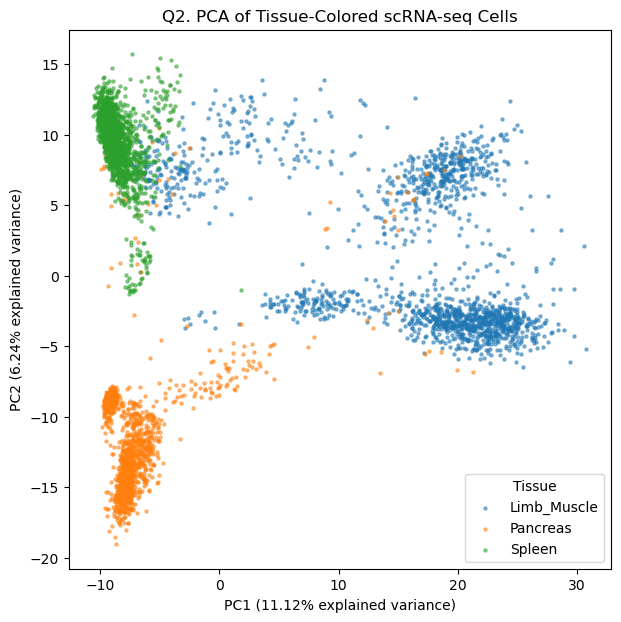

In [5]:
# TODO:
# 3. Apply PCA (50 components)
# 4. Plot first 2 PCs colored by tissue
n_components = 50
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(adata_hvg.X)
adata_hvg.obsm["X_pca"] = X_pca

fig, ax = plt.subplots(figsize=(7, 7))

for tissue in np.unique(adata_hvg.obs["tissue"]):
    m = (adata_hvg.obs["tissue"] == tissue).values
    ax.scatter(X_pca[m, 0], X_pca[m, 1], s=5, alpha=0.5, label=tissue)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} explained variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} explained variance)")
ax.set_title("Q2. PCA of Tissue-Colored scRNA-seq Cells")
ax.legend(title="Tissue")

# Save plot (WILL BE GRADED)
# save figure to ('figs/pca_by_tissue.png')
fig.savefig("figs/pca_by_tissue.png")
plt.show()


#### Interpretation (written) question:

*Answer in PDF:*

Do the tissues separate in PCA space? Explain your observation.


## 3. K-means Clustering (20 pts)
Determine optimal K and compare clusters to tissue labels.

k=2  inertia=2882618.01  silhouette=0.31
k=3  inertia=2470011.34  silhouette=0.27
k=4  inertia=2131317.60  silhouette=0.31
k=5  inertia=1898970.49  silhouette=0.37
k=6  inertia=1748124.29  silhouette=0.40
best_k = 6
KMeans  k=6  Sil=0.397  ARI=0.604  NMI=0.665
tissue   Limb_Muscle  Pancreas  Spleen
cluster                               
0                977        11       0
1                167        22    1573
2                  0       917       0
3                  0       678       0
4                 97         8     113
5                421        16       0


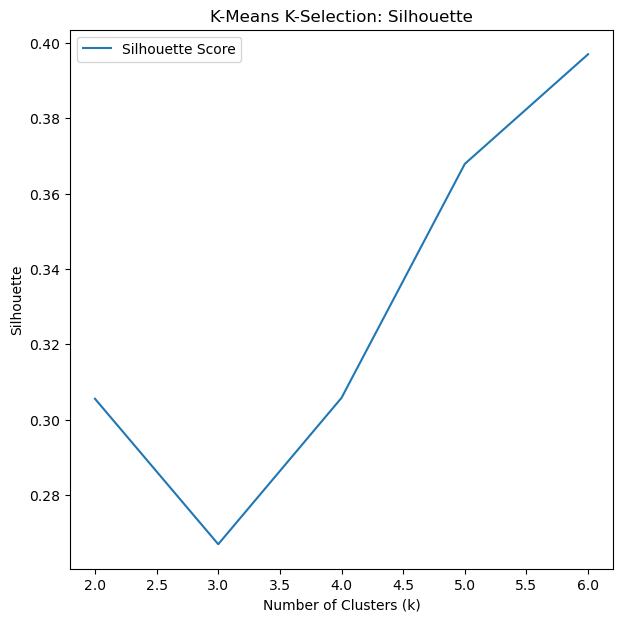

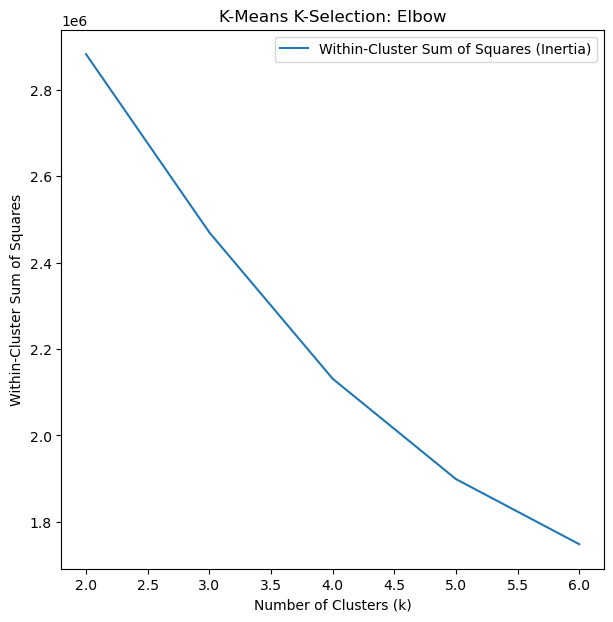

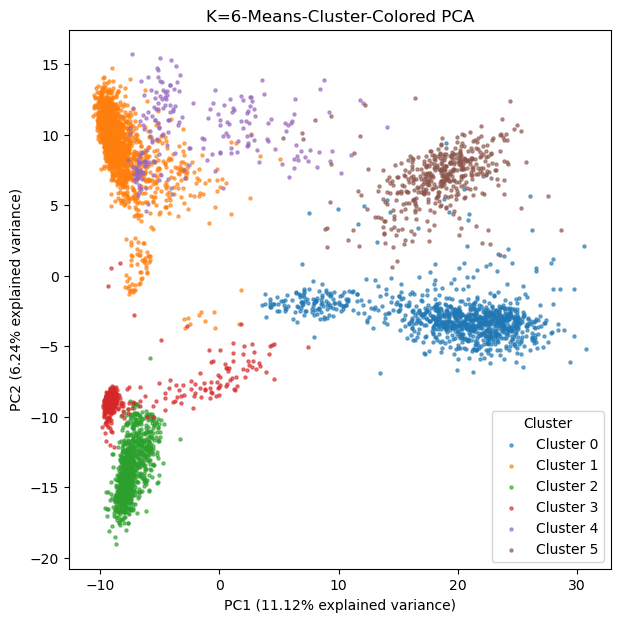

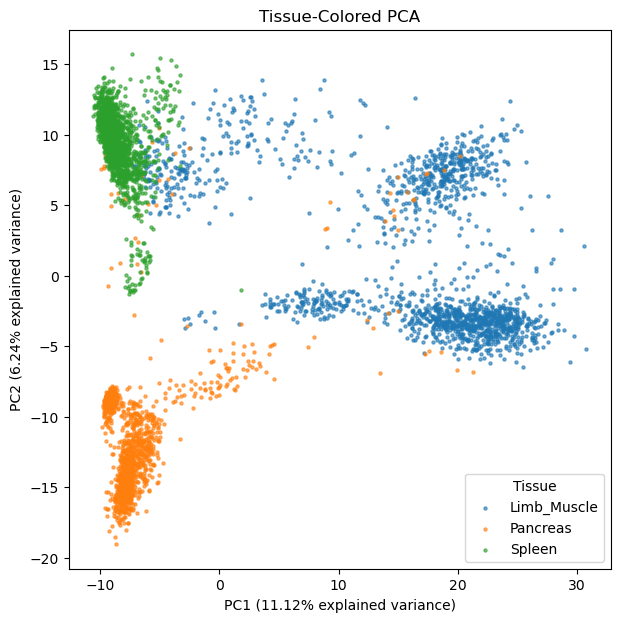

In [9]:
# TODO:
# import the tools you will use
from sklearn.metrics import normalized_mutual_info_score


N_PCS   = 50
K_RANGE = [2, 3, 4, 5, 6]
SEED    = 42
LABEL_COL = "tissue"

# TODO: ensure you are using exactly the first N_PCS PCs
X_pca_use = adata_hvg.obsm["X_pca"][:, :N_PCS]
y_true = adata_hvg.obs[LABEL_COL].values

# TODO: compute elbow (inertia) and silhouette over K_RANGE (use random_state=SEED, n_init=50)
elbow, silhouette = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=50).fit(X_pca_use)
    elbow.append(km.inertia_)
    silhouette.append(silhouette_score(X_pca_use, km.labels_))
    print(f"k={k}  inertia={km.inertia_:.2f}  silhouette={silhouette[-1]:.2f}")

# TODO: choose best_k by max silhouette; if tie, pick the smaller k
best_k = K_RANGE[int(np.argmax(silhouette))]  # argmax returns the first max, i.e. the smaller k on ties
print("best_k =", best_k)

# TODO: fit final KMeans with best_k (use random_state=SEED, n_init=50)
km_final = KMeans(n_clusters=best_k, random_state=SEED, n_init=50).fit(X_pca_use)
km_labels = km_final.labels_

# TODO: compute metrics (silhouette, ARI, NMI) using (X_pca_use, km_labels, y_true)
km_sil = silhouette_score(X_pca_use, km_labels)
km_ari = adjusted_rand_score(y_true, km_labels)
km_nmi = normalized_mutual_info_score(y_true, km_labels)
print(f"KMeans  k={best_k}  Sil={km_sil:.3f}  ARI={km_ari:.3f}  NMI={km_nmi:.3f}")

# TODO: print or draw confusion table clusters × tissue
# optionally save to -> outputs/kmeans_confusion.csv
confusion = pd.crosstab(pd.Series(km_labels, name="cluster"), pd.Series(y_true, name="tissue"))
confusion.to_csv("outputs/kmeans_confusion.csv")
print(confusion)

# TODO: plot and save k-selection curves (Elbow + Silhouette)
# save figure in -> figs/kmeans_kselection_silhouette.png
# save figure in -> figs/kmeans_kselection_elbow.png
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(K_RANGE, silhouette, label="Silhouette Score")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette")
ax.set_title("K-Means K-Selection: Silhouette")
ax.legend()
fig.savefig("figs/kmeans_kselection_silhouette.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(K_RANGE, elbow, label="Within-Cluster Sum of Squares (Inertia)")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Within-Cluster Sum of Squares")
ax.set_title("K-Means K-Selection: Elbow")
ax.legend()
fig.savefig("figs/kmeans_kselection_elbow.png")
plt.show()

# TODO: PCA scatter (PC1 vs PC2) colored by KMeans clusters →
# save figure in -> figs/pca_kmeans.png
fig, ax = plt.subplots(figsize=(7, 7))

for c in np.unique(km_labels):
    m = km_labels == c
    ax.scatter(X_pca_use[m, 0], X_pca_use[m, 1], s=5, alpha=0.6, label=f"Cluster {c}")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} explained variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} explained variance)")
ax.set_title(f"K={best_k}-Means-Cluster-Colored PCA")
ax.legend(title="Cluster")

fig.savefig("figs/pca_kmeans.png")
plt.show()

# TODO: PCA scatter (PC1 vs PC2) colored by tissue
# save figure in -> figs/pca_tissue.png
fig, ax = plt.subplots(figsize=(7, 7))

for t in np.unique(y_true):
    m = y_true == t
    ax.scatter(X_pca_use[m, 0], X_pca_use[m, 1], s=5, alpha=0.6, label=t)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} explained variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} explained variance)")
ax.set_title("Tissue-Colored PCA")
ax.legend(title="Tissue")

fig.savefig("figs/pca_tissue.png")
plt.show()


#### Interpretation (written) question:

*Answer in PDF:*

How well do clusters align with tissue labels?

## 4. Alternative Clustering Method (20 pts)
Apply graph-based or hierarchical Clustering

KMeans        k=6  Sil=0.397  ARI=0.604  NMI=0.665
Agglomerative k=6  Sil=0.395  ARI=0.522  NMI=0.589
tissue   Limb_Muscle  Pancreas  Spleen
cluster                               
0                328        94     201
1                780         9       0
2                147        34    1485
3                407        15       0
4                  0       586       0
5                  0       914       0


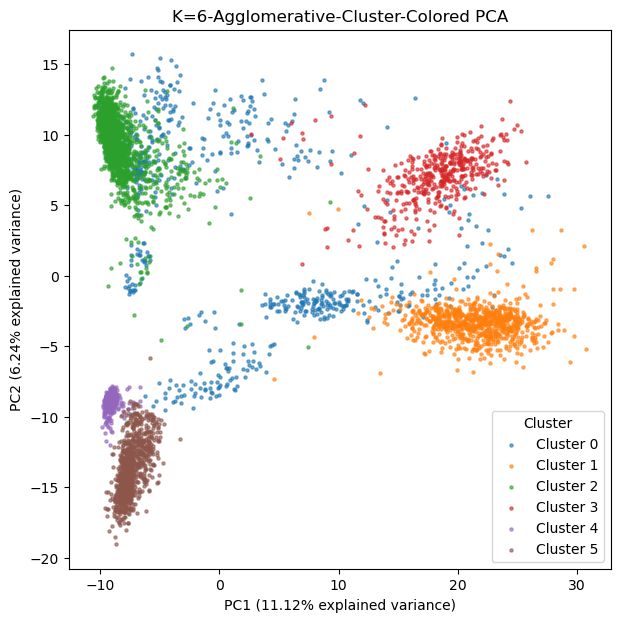

In [7]:
# Use Hierarchical or Graph-based (Leiden/Louvain) clustering as alternative clustering method
from sklearn.cluster import AgglomerativeClustering

# TODO: Perform Louvain or Agglomerative (hierarchical) clustering on PCA-reduced data
# Ward linkage, same number of clusters as k-means for a fair comparison
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(X_pca_use)

# TODO: Save the resulting cluster labels
adata_hvg.obs["agglomerative"] = agg_labels.astype(str)
pd.DataFrame({"cell": adata_hvg.obs_names, "agglomerative": agg_labels}).to_csv("outputs/agglomerative_labels.csv", index=False)

# TODO: Calculate silhouette score for k-means clusters (already computed earlier)
# already computed earlier as km_sil, km_ari, km_nmi in Section 3

# TODO: Calculate silhouette score for your new clusters
agg_sil = silhouette_score(X_pca_use, agg_labels)
agg_ari = adjusted_rand_score(y_true, agg_labels)
agg_nmi = normalized_mutual_info_score(y_true, agg_labels)

# TODO: Print or display all silhouette scores for comparison (including k-means)
print(f"KMeans        k={best_k}  Sil={km_sil:.3f}  ARI={km_ari:.3f}  NMI={km_nmi:.3f}")
print(f"Agglomerative k={best_k}  Sil={agg_sil:.3f}  ARI={agg_ari:.3f}  NMI={agg_nmi:.3f}")
print(pd.crosstab(pd.Series(agg_labels, name="cluster"), pd.Series(y_true, name="tissue")))

# TODO: Plot results (PCA) for new clusters (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(7, 7))

for c in np.unique(agg_labels):
    m = agg_labels == c
    ax.scatter(X_pca_use[m, 0], X_pca_use[m, 1], s=5, alpha=0.6, label=f"Cluster {c}")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} explained variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} explained variance)")
ax.set_title(f"K={best_k}-Agglomerative-Cluster-Colored PCA")
ax.legend(title="Cluster")

fig.savefig("figs/pca_agglomerative.png")
plt.show()


#### Interpretation (written) question:

*Answer in PDF:*

How does your alternative clustering method compare to k-means clustering?

## 5. Marker Gene Identification (15 pts)
Find top 5 marker genes for one cluster using differential expression. In this part you just make the following code work with your data. You may variable names and structure while maintaining functionality.

In [8]:
# Marker gene identification for each cluster

# Expression matrix: cells × genes (from preprocessed HVG data)
expression_matrix = adata_hvg.to_df()

# Choose cluster assignments (KMeans, Leiden, or Hierarchical)
cluster_assignments = agg_labels   # using agglomerative (hierarchical) clusters
y_true = adata_hvg.obs["tissue"].values

all_markers = {}

for cluster in np.unique(cluster_assignments):
    # TODO: make a boolean mask for cells in this cluster
    mask = cluster_assignments == cluster

    # TODO: find the majority tissue among cells in this cluster
    majority_tissue = pd.Series(y_true[mask]).mode()[0]

    # TODO: loop over all genes and compute Welch’s t-test (target vs other cells)
    scores, pvals = [], []
    for g in range(expression_matrix.shape[1]):
        expr_target = expression_matrix.iloc[:, g].values[mask]
        expr_other = expression_matrix.iloc[:, g].values[~mask]
        t_stat, p_val = stats.ttest_ind(expr_target, expr_other, equal_var=False)
        scores.append(t_stat)
        pvals.append(p_val)

    # Multiple testing correction (already provided)
    _, pvals_adj, _, _ = multipletests(pvals, method="fdr_bh")

    # Collect results for this cluster
    markers = pd.DataFrame({
        "gene": expression_matrix.columns,
        "t_stat": scores,
        "pval": pvals,
        "pval_adj": pvals_adj,
        # TODO: compute log fold change (mean target − mean other)
        "logFC": expression_matrix.values[mask].mean(axis=0) - expression_matrix.values[~mask].mean(axis=0)
    })

    # TODO: filter markers by adjusted p-value < 0.05
    # HINT: use markers[markers["pval_adj"] < 0.05]
    # TODO: then rank by absolute logFC and select top 5
    markers = markers[markers["pval_adj"] < 0.05]
    top5 = markers.reindex(markers["logFC"].abs().sort_values(ascending=False).index).head(5)

    all_markers[cluster] = top5
    print(f"\nTop 5 Marker Genes for Cluster: {cluster}\nMajority Tissue: {majority_tissue}")
    print(top5)

    # Save results per cluster
    top5.to_csv(f"outputs/top5_markers_cluster{cluster}.csv", index=False)

print("\nMarker gene identification complete. Results saved in outputs/ folder.")


/opt/homebrew/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



Top 5 Marker Genes for Cluster: 0
Majority Tissue: Limb_Muscle
         gene     t_stat          pval      pval_adj     logFC
228      Lyz2  18.614117  6.988998e-62  1.644470e-60  1.647175
229      Lyz1  18.086268  4.002017e-59  8.893370e-58  1.630554
1387  Alox5ap  18.868218  2.735280e-63  6.671415e-62  1.588835
126    Fcer1g  19.842448  1.261747e-68  3.277264e-67  1.520671
1594   Tyrobp  19.995936  1.568354e-69  4.182276e-68  1.482055


/opt/homebrew/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



Top 5 Marker Genes for Cluster: 1
Majority Tissue: Limb_Muscle
          gene      t_stat  pval  pval_adj     logFC
214        Dcn  180.478883   0.0       0.0  2.592548
657     Igfbp6   91.361851   0.0       0.0  2.510643
310   Serpinf1   77.148487   0.0       0.0  2.458640
1374    Pcolce   75.863416   0.0       0.0  2.418495
948        Gsn  115.032868   0.0       0.0  2.415744


/opt/homebrew/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


...


Top 5 Marker Genes for Cluster: 3
Majority Tissue: Limb_Muscle
       gene     t_stat           pval       pval_adj     logFC
1803   Cdh5  53.112216  4.179854e-190  2.786569e-188  3.172403
1066  Fabp4  65.562284  2.432059e-228  5.404576e-226  3.104364
1852   Esam  48.460475  7.513300e-176  3.130542e-174  3.061645
1166   Emcn  33.193206  8.170355e-120  1.201523e-118  2.919416
937   Egfl7  37.118130  1.846013e-135  3.619633e-134  2.912043


/opt/homebrew/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



Top 5 Marker Genes for Cluster: 4
Majority Tissue: Pancreas
          gene      t_stat  pval  pval_adj     logFC
922   Pnliprp2  218.210562   0.0       0.0  2.981798
1680       Gp2  152.312374   0.0       0.0  2.969502
1352   Pla2g1b  268.921042   0.0       0.0  2.957236
1404      Cpa2  302.418879   0.0       0.0  2.942586
750       Tff2  156.621913   0.0       0.0  2.934609


/opt/homebrew/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



Top 5 Marker Genes for Cluster: 5
Majority Tissue: Pancreas
        gene      t_stat  pval  pval_adj     logFC
1016   Pcsk2  221.293302   0.0       0.0  2.540945
1946  Pcsk1n  195.318521   0.0       0.0  2.525706
427     Chga  187.859779   0.0       0.0  2.521773
41      Scg2  127.272595   0.0       0.0  2.483262
1545    Iapp  178.302140   0.0       0.0  2.475792

Marker gene identification complete. Results saved in outputs/ folder.


#### Interpretation (written) question:

*Answer in PDF:*

Are the identified markers similar for different tissues? Explain briefly why they are or are not similar.